# Otimização de Descarregamento de Balsa

Este trabalho visa encontrar a solução ótima para o problema de descarregamento e locomoção de containers em portos.

Os objetivos principais são:
- Garantir um descarrecamento mantendo a estabilidade da embarcação
- Garantir que os containers sejam retirados na melhor ordem para sua locomoção
- Garantir a melhor rota para a entrega dos containers

### Bibliotecas

In [1]:
import numpy as np
import random
import copy
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

### Constantes

In [ ]:
num_individuos = 100
margem_erro = 15
num_containers = 24
num_geracoes = 300

# Valores a serem modificados
fator_CL = 3.8
tam_barco = 50

x = 12  # Peso do cotainer
tipo_container = {"vermelho": 2 * x, "azul": x}

barco = np.array(
    [
        [  # Primeiro andar
            [1, 0, 0, 0],
            [1, 1, 1, 1],
            [1, 1, 1, 1],
            [0, 1, 0, 1],
        ],
        [  # Segundo andar
            [1, 0, 0, 0],
            [1, 1, 1, 1],
            [1, 1, 1, 1],
            [0, 1, 0, 0],
        ],
        [  # Terceiro andar
            [0, 0, 0, 0],
            [0, 1, 0, 0],
            [0, 1, 1, 0],
            [0, 0, 0, 0],
        ],
    ]
)

### Rotas e Grafo
| Destino  | Carga |
|--------|---------|
| Urutau | 2x + x  |
| Baja | 2x + x |
| Samsung Ocean | 2x + x |
| Hub de inovação | 2x + x |
| Sala A18 | 2x |
| Sala C18 | 2x |
| Callidus | 2x |
| Escada Biblioteca | 2x |
| Escadaria Entrada | 2x |
| FemtonLab | 2x |
| Quadra | x |
| Sala A4 | x |

In [10]:
G = nx.Graph()

destinos = {
    "Urutau": {"carga": "misto"},
    "Baja": {"carga": "misto"},
    "Ocean": {"carga": "misto"},
    "Hub": {"carga": "misto"},
    "Sala A18": {"carga": "vermelho"},
    "Sala C18": {"carga": "vermelho"},
    "Callidus": {"carga": "vermelho"},
    "Escadaria biblioteca": {"carga": "vermelho"},
    "Escadaria entrada": {"carga": "vermelho"},
    "FemtonLab": {"carga": "vermelho"},
    "Quadra": {"carga": "azul"},
    "Sala A4": {"carga": "azul"},
}

rotas_intermediarias = [
    "jambeiro",
    "jambeiro Saída 1",
    "Corredor Bloco A-B-1.1",
    "Corredor Bloco A-B-1.2",
    "Corredor Bloco A-B-1.3",
    "Corredor Bloco A-B-1.4",
    "Corredor Daetec 1",
    "Corredor B-1.1",
    "Corredor B-1.2",
    "jambeiro Saída 2",
    "Cruza Bloco B->A",
    "Corredor Transicao B->C",
    "Corredor Bloco B-C-1.1",
    "Corredor Bloco B-C-1.2",
    "Corredor Bloco B-C-1.3",
    "Corredor Bloco B-C-1.4",
    "Corredor Bloco C-1.1",
    "Corredor Bloco C-1.2",
    "Corredor Bloco C-1.3",
    "Corredor Bloco C-1.4",
    "Corredor Bloco D-1.1",
    "Corredor Bloco D-1.2",
    "Corredor Bloco D-1.3",
    "Entrada",
    "Entrada lado da Quadra",
    "Entrada lado do Campo",
    "Corredor STEM-RU",
    "Corredor STEM-OCEAN",
]

conexoes = {
    "no_1": ("jambeiro", "jambeiro Saída 1"),
    "no_2": ("jambeiro Saída 1", "Corredor Bloco A-B-1.2"),
    "no_3": ("Corredor Bloco A-B-1.2", "Corredor Bloco A-B-1.1"),
    "no_4": ("Corredor Bloco A-B-1.1", "Sala A4"),
    "no_5": ("Corredor Bloco A-B-1.1", "Corredor Daetec 1"),
    "no_6": ("Corredor Daetec 1", "Entrada"),
    "no_7": ("Entrada", "Escadaria entrada"),
    "no_8": ("Entrada", "Hub"),
    "no_9": ("Entrada", "Escadaria biblioteca"),
    "no_10": ("Entrada", "Callidus"),
    "no_11": ("Entrada", "Corredor Bloco B-C-1.1"),
    "no_12": ("Escadaria entrada", "Hub"),
    "no_13": ("Escadaria entrada", "Escadaria biblioteca"),
    "no_14": ("Hub", "Callidus"),
    "no_15": ("Callidus", "FemtonLab"),
    "no_16": ("Callidus", "Corredor Bloco D-1.3"),
    "no_17": ("Callidus", "Quadra"),
    "no_18": ("FemtonLab", "Quadra"),
    "no_19": ("Corredor Bloco D-1.3", "Entrada lado da Quadra"),
    "no_20": ("Corredor Bloco D-1.3", "Entrada lado do Campo"),
    "no_21": ("FemtonLab", "Entrada lado da Quadra"),
    "no_22": ("FemtonLab", "Entrada lado do Campo"),
    "no_23": ("FemtonLab", "Urutau"),
    "no_24": ("FemtonLab", "Corredor STEM-RU"),
    "no_25": ("FemtonLab", "Corredor STEM-OCEAN"),
    "no_26": ("Urutau", "Entrada lado da Quadra"),
    "no_27": ("Ocean", "Corredor STEM-OCEAN"),
    "no_28": ("Ocean", "Corredor STEM-RU"),
    "no_29": ("Ocean", "Quadra"),
    "no_30": ("Ocean", "Baja"),
    "no_31": ("Ocean", "Escadaria biblioteca"),
    "no_32": ("Ocean", "Corredor Bloco D-1.3"),
    "no_33": ("Baja", "Escadaria biblioteca"),
    "no_34": ("Baja", "Corredor STEM-OCEAN"),
    "no_35": ("Baja", "Corredor STEM-RU"),
    "no_36": ("Baja", "Entrada lado da Quadra"),
    "no_37": ("Baja", "Entrada lado do Campo"),
    "no_38": ("Baja", "Corredor Bloco D-1.3"),
    "no_39": ("Quadra", "Entrada lado da Quadra"),
    "no_40": ("Quadra", "Entrada lado do Campo"),
    "no_41": ("Quadra", "Corredor Bloco D-1.3"),
    "no_42": ("Quadra", "Corredor STEM-RU"),
    "no_43": ("Quadra", "Corredor STEM-OCEAN"),
    "no_44": ("Corredor Bloco D-1.3", "Corredor Bloco D-1.1"),
    "no_45": ("Corredor Bloco D-1.3", "Corredor Bloco D-1.2"),
    "no_46": ("Corredor Bloco D-1.2", "Corredor Bloco C-1.2"),
    "no_47": ("Corredor Bloco C-1.2", "Corredor Bloco C-1.1"),
    "no_48": ("Corredor Bloco C-1.2", "Sala C18"),
    "no_49": ("Corredor Bloco C-1.2", "Corredor Bloco C-1.3"),
    "no_50": ("Corredor Bloco C-1.3", "Corredor Bloco C-1.4"),
    "no_51": ("Corredor Bloco C-1.4", "Corredor Bloco B-C-1.1"),
    "no_52": ("Corredor Bloco C-1.4", "Corredor Bloco B-C-1.2"),
    "no_53": ("Corredor Bloco B-C-1.2", "Corredor Transicao B->C"),
    "no_54": ("Corredor Bloco B-C-1.2", "Corredor Bloco B-C-1.3"),
    "no_55": ("Corredor Bloco B-C-1.3", "Corredor Bloco C-1.1"),
    "no_56": ("Corredor Bloco B-C-1.3", "Corredor Bloco B-C-1.4"),
    "no_57": ("Corredor Bloco B-C-1.4", "Corredor Bloco D-1.3"),
    "no_58": ("Corredor Bloco D-1.1", "Corredor Bloco A-B-1.4"),
    "no_59": ("Corredor Bloco A-B-1.4", "Corredor Bloco A-B-1.3"),
    "no_60": ("Corredor Bloco A-B-1.4", "Sala A18"),
    "no_61": ("Corredor Bloco A-B-1.3", "Corredor Bloco A-B-1.2"),
    "no_62": ("Corredor Daetec 1", "Corredor B-1.1"),
    "no_63": ("Corredor B-1.1", "Cruza Bloco B->A"),
    "no_64": ("Cruza Bloco B->A", "jambeiro Saída 2"),
    "no_65": ("Corredor B-1.1", "Corredor B-1.2"),
    "no_66": ("Corredor B-1.2", "Corredor Transicao B->C"),
    "no_67": ("Corredor Bloco A-B-1.3", "Sala A18"),
}

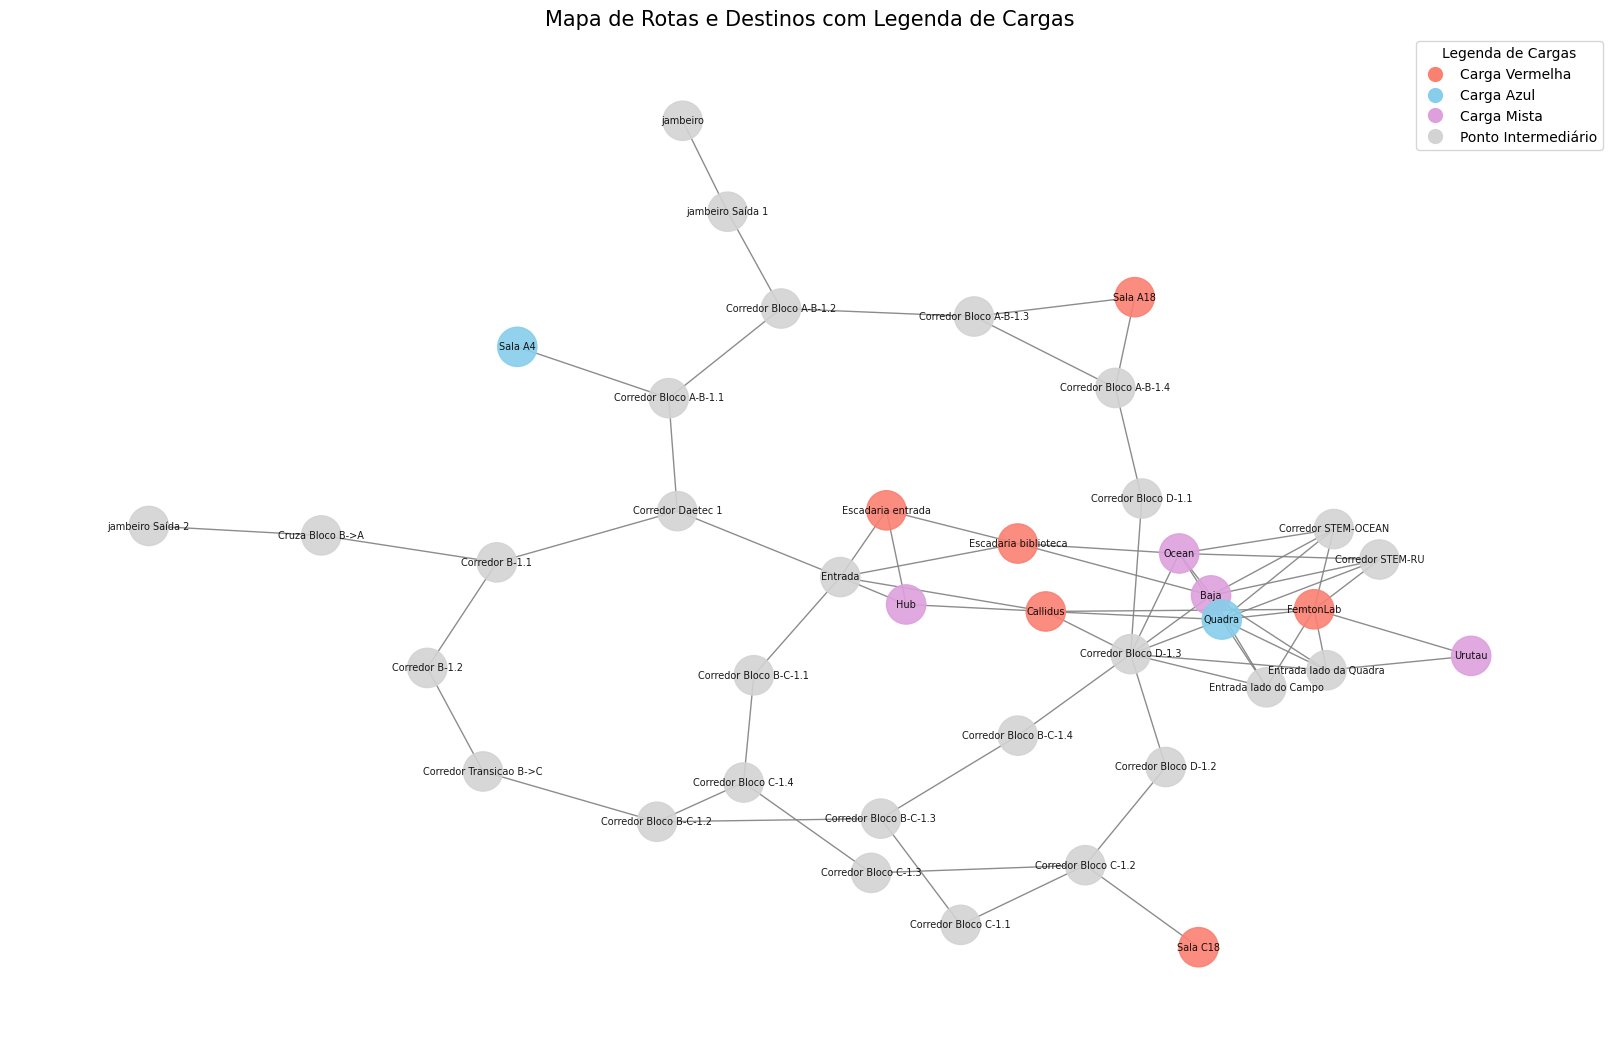

Total de nós: 40
Total de arestas: 67


In [17]:
G.add_nodes_from(destinos.keys())
nx.set_node_attributes(G, destinos)

G.add_nodes_from(rotas_intermediarias)

for u, v in conexoes.values():
    G.add_edge(u, v)

plt.figure(figsize=(16, 10))
pos = nx.kamada_kawai_layout(G)  # Layout que evita sobreposição

# Definindo cores dos nós
color_map = []
for node in G:
    if node in destinos:
        carga = destinos[node].get("carga")
        if carga == "vermelho":
            color_map.append("salmon")
        elif carga == "azul":
            color_map.append("skyblue")
        else:
            color_map.append("plum")  # Misto
    else:
        color_map.append("lightgrey")  # Intermediários

nx.draw(G, pos, with_labels=True, node_color=color_map, 
        node_size=800, font_size=7, edge_color="gray", alpha=0.9)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Carga Vermelha',
           markerfacecolor='salmon', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Carga Azul',
           markerfacecolor='skyblue', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Carga Mista',
           markerfacecolor='plum', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Ponto Intermediário',
           markerfacecolor='lightgrey', markersize=12)
]

plt.legend(handles=legend_elements, loc='upper right', title="Legenda de Cargas", fontsize=10)

plt.title("Mapa de Rotas e Destinos com Legenda de Cargas", fontsize=15)
plt.axis('off') # Remove os eixos para limpar o visual
plt.show()


print(f"Total de nós: {G.number_of_nodes()}")
print(f"Total de arestas: {G.number_of_edges()}")

## AG

In [ ]:
class Argo:
    def __init__(
        self,
        barco: list,
        margem_erro: int = 15,
        num_containers: int = 20,
        tam_populacao: int = 100,
        p_mutacao: float = 0.1,  # Evitar minimos locais
        p_crossover: float = 0.8,
        num_geracoes: int = 100,
    ):
        self.barco = barco
        self.num_containers = num_containers
        self.tam_populacao = tam_populacao
        self.p_mutacao = p_mutacao
        self.p_crossover = p_crossover
        self.num_geracoes = num_geracoes
        self.tam_cromossomos = self.num_containers + margem_erro
        self.populacao = [self.gerar_cromossomo() for _ in range(self.tam_populacao)]
        # Variáveis para armazenar o histórico
        self.historico_melhor_individuo = []
        self.historico_media = []
        self.pier = np.zeros((3, 2, 2))

    def garra(self, garra_pos_atual: tuple[int, int], alvo_y: int, alvo_x: int):
        """Reproz o movimento da garra que pega os containers"""

        movimentos = abs(garra_pos_atual[0] - alvo_y) + abs(garra_pos_atual[1] - alvo_x)
        nova_posicao = (alvo_y, alvo_x)
        return movimentos, nova_posicao

    def verificar_container_abaixo(self, matriz: np.ndarray, y: int, x: int, acao: str):
        """Verifica se existe um container abaixo"""

        match acao:
            case "pegar":
                for z in range(matriz.shape[0] - 1, -1, -1):
                    if matriz[z, y, x] == 1:
                        return z
                return -1
            case "largar":
                for z in range(matriz.shape[0]):
                    if matriz[z, y, x] == 0:
                        return z
                return -1
            case _:
                return -1

    def calcular_estabilidade(self, barco_aux: np.ndarray, peso_total_barco: float):
        """Calcula o centro de massa e retorna a penalidade caso esteja instável."""
        if peso_total_barco > 0:
            pesos_x = np.sum(barco_aux, axis=(0, 1))
            centro_massa_x = np.sum(pesos_x * np.arange(4)) / peso_total_barco

            if abs(centro_massa_x - 1.5) > 1.0:
                return 50.0  # penalidade

        return 0.0

    def funcao_fitness(self, cromossomo: np.ndarray):
        """
        Penaliza movimentos inválidos e instabilidade.
        No entanto, recompensa menor custo na distância percorrida.
        """

        barco_aux = copy.deepcopy(self.barco)
        pier_aux = copy.deepcopy(self.pier)

        movimentos_totais = 0
        penalidade = 0.0
        posicao_garra = (0, 0)
        peso_total_barco = int(np.sum(barco_aux))

        for acao in cromossomo:
            if int(np.sum(barco_aux)) == 0:
                break

            barco_y, barco_x, pier_y, pier_x = acao

            pegar_z = self.verificar_container_abaixo(
                barco_aux, barco_y, barco_x, "pegar"
            )

            if pegar_z == -1:
                penalidade += 500.0  # modificar conforme necessidade
                continue

            barco_aux[pegar_z, barco_y, barco_x] = 0

            movimento, posicao_garra = self.garra(posicao_garra, barco_y, barco_x)
            movimentos_totais += movimento

            peso_total_barco -= 1
            penalidade += self.calcular_estabilidade(barco_aux, peso_total_barco)

            largar_z = self.verificar_container_abaixo(
                pier_aux, pier_y, pier_x, "largar"
            )

            if largar_z == -1:
                penalidade += 500.0
                barco_aux[pegar_z, barco_y, barco_x] = 1
                peso_total_barco += 1
                continue

            pier_aux[largar_z, pier_y, pier_x] = 1

            movimento, posicao_garra = self.garra(posicao_garra, pier_y, pier_x)
            movimentos_totais += movimento

        containers_restantes = int(np.sum(barco_aux))
        penalidade += (
            containers_restantes**2
        ) * 1000000.0  # Tentando evitar que cotainers fiquem no barco

        custo_total = movimentos_totais + penalidade
        return 10000.0 / (custo_total + 1.0)

    def decodificar(self, cromossomo: list):
        """Decodifica o cromossomo para obter as localizações iniciais e finais no descarregamento."""

        inicial_x = cromossomo[0]
        inicial_y = cromossomo[1]
        inicial_z = cromossomo[2]
        final_x = cromossomo[3]
        final_y = cromossomo[4]
        final_z = cromossomo[5]

        return inicial_x, inicial_y, inicial_z, final_x, final_y, final_z

    def gerar_cromossomo(self):
        """
        Gera cromossomos com coordenadas aleatórios de posicionamento barco -> pier.
        """
        cromossomo = []

        for _ in range(self.tam_cromossomos):
            barco_y, barco_x = random.randint(0, 3), random.randint(0, 3)
            pier_y, pier_x = random.randint(0, 4), random.randint(0, 1)
            cromossomo.append([barco_y, barco_x, pier_y, pier_x])
        return np.array(cromossomo)

    def inicializar_otimização(self):
        """Inicializa otimização."""
        for gen in range(self.num_geracoes):
            fitnesses = [self.funcao_fitness(individuo) for individuo in self.populacao]

            melhor_idx = int(np.argmax(fitnesses))
            melhor_fitness = fitnesses[melhor_idx]
            melhor_individuo = self.populacao[melhor_idx].copy()

            print(f"Geração {gen} | Melhor Fitness: {melhor_fitness:.4f}")

            self.historico_melhor_individuo.append(melhor_fitness)
            self.historico_media.append(float(np.mean(fitnesses)))

            nova_população = []
            nova_população.append(melhor_individuo)  # Elitismo

            while len(nova_população) < self.tam_populacao:
                pai = self.torneio(fitnesses)
                mae = self.torneio(fitnesses)

                primogenito, ultimogênito = self.crossover(pai, mae)

                self.mutar(primogenito)
                self.mutar(ultimogênito)

                nova_população.append(primogenito)

                if len(nova_população) < self.tam_populacao:
                    nova_população.append(ultimogênito)
            self.populacao = nova_população

        return self.historico_melhor_individuo, self.historico_media, self.populacao[0]

    def torneio(self, fitnesses: list[float], num_competidores: int = 3):
        """Seleciona por torneio. Minimizar perda de diversidade"""
        participantes = random.sample(range(self.tam_populacao), num_competidores)
        ganhador = max(participantes, key=lambda idx: fitnesses[idx])
        return self.populacao[ganhador].copy()

    def crossover(self, pai: np.ndarray, mae: np.ndarray):
        """Crossover de 2 pontos na sequência de ações"""
        if np.random.rand() < self.p_crossover:
            ponto = np.random.randint(2, self.tam_cromossomos - 1)
            primogenito = np.concatenate([pai[:ponto], mae[ponto:]])
            ultimogênito = np.concatenate([mae[:ponto], pai[ponto:]])
            return primogenito, ultimogênito
        return pai.copy(), mae.copy()

    def mutar(self, individuo: np.ndarray):
        """Altera uma coordenada aleatoriamente."""
        for i in range(self.tam_cromossomos):
            if np.random.rand() < self.p_mutacao:
                individuo[i][0] = random.randint(0, 3)
                individuo[i][1] = random.randint(0, 3)
            else:
                individuo[i][2] = random.randint(0, 4)
                individuo[i][3] = random.randint(0, 1)

    def visualizar_resultado_final(self, melhor_cromossomo: np.ndarray) -> None:
        """Simula a melhor sequência de ações e imprime como os containers ficaram empilhados."""
        barco_sim = copy.deepcopy(self.barco)
        pier_sim = copy.deepcopy(self.pier)

        for acao in melhor_cromossomo:
            if int(np.sum(barco_sim)) == 0:
                break

            b_y, b_x, p_y, p_x = acao

            z_pegou = self.verificar_container_abaixo(barco_sim, b_y, b_x, "pegar")
            if z_pegou != -1:
                barco_sim[z_pegou, b_y, b_x] = 0

                z_largou = self.verificar_container_abaixo(pier_sim, p_y, p_x, "largar")
                if z_largou != -1:
                    pier_sim[z_largou, p_y, p_x] = 1
                else:
                    barco_sim[z_pegou, b_y, b_x] = 1

        print("\n" + "=" * 40)
        print("RESULTADO FINAL DO DESCARREGAMENTO")
        print("=" * 40)

        for z in range(pier_sim.shape[0] - 1, -1, -1):
            print(f"\nNÍVEL Z = {z} (Andar {z + 1}):")
            print("  Col 0  Col 1")
            for y in range(pier_sim.shape[1]):
                linha = pier_sim[z, y]
                visual = [" [X] " if val == 1 else " [ ] " for val in linha]
                print(f"L{y}:" + "".join(visual))

        print("\n" + "-" * 50)
        containers_restantes = int(np.sum(barco_sim))
        if containers_restantes == 0:
            print("SUCESSO: Todos os containers foram descarregados!")
        else:
            print(f"AVISO: Ficaram {containers_restantes} containers no barco.")
        print("=" * 50 + "\n")

    def passo_a_passo(self, melhor_cromossomo: np.ndarray):
        """Imprime o passo a passo do melhor resultado"""
        barco_sim: np.ndarray = copy.deepcopy(self.barco)
        pier_sim = copy.deepcopy(self.pier)

        print("\n" + "=" * 40)
        print("Descarregamento Passo a Passo")
        print("=" * 40)

        movimentos_validos = 0
        movimentos_invalidos = 0

        for i, acao in enumerate(melhor_cromossomo):
            if int(np.sum(barco_sim)) == 0:
                break

            b_y, b_x, p_y, p_x = acao
            passo = i + 1

            z_pegou = self.verificar_container_abaixo(barco_sim, b_y, b_x, "pegar")

            if z_pegou == -1:
                movimentos_invalidos += 1
                continue

            barco_sim[z_pegou, b_y, b_x] = 0

            z_largou = self.verificar_container_abaixo(pier_sim, p_y, p_x, "largar")

            if z_largou == -1:
                barco_sim[z_pegou, b_y, b_x] = 1
                movimentos_invalidos += 1
                continue

            pier_sim[z_largou, p_y, p_x] = 1

            print(f"Passo {passo:02d}:")
            print(
                f"Garra retira do barco (Y:{b_y + 1}, X:{b_x + 1}) no andar Z:{z_pegou + 1}"
            )
            print(
                f"Deixa no pier (Y:{p_y + 1}, X:{p_x + 1}) no andar Z:{z_largou + 1}\n"
            )
            movimentos_validos += 1

        print("\n" + "-" * 50)
        print(f"Acertos: {movimentos_validos}")
        print(f"Erros penalizados: {movimentos_invalidos}")
        print("=" * 50 + "\n")


## Teste

In [ ]:
tentativas = 1
is_empty_boat = False
while not is_empty_boat:
    print(f"Iniciando Algoritmo Genético Argo - Tentativa {tentativas}\n")
    argo_ag: Argo = Argo(
        barco=barco,
        margem_erro=margem_erro,
        num_geracoes=num_geracoes,
        tam_populacao=num_individuos,
        num_containers=num_containers,
    )
    melhor_hist, media_hist, melhor_individuo = argo_ag.inicializar_otimização()

    # testa o melhor individuo para checar se o barco está vazio
    barco_teste = copy.deepcopy(barco)
    pier_teste = np.zeros((2, 5, 2))
    for acao in melhor_individuo:
        b_y, b_x, p_y, p_x = acao

        z_pegou = argo_ag.verificar_container_abaixo(barco_teste, b_y, b_x, "pegar")
        if z_pegou != -1:
            barco_teste[z_pegou, b_y, b_x] = 0

            z_largou = argo_ag.verificar_container_abaixo(
                pier_teste, p_y, p_x, "largar"
            )
            if z_largou != -1:
                pier_teste[z_largou, p_y, p_x] = 1
            else:
                barco_teste[z_pegou, b_y, b_x] = 1

    restantes = int(np.sum(barco_teste))

    if restantes == 0:
        is_empty_boat = True
    else:
        tentativas += 1
        print(f"A solução falhou! Restaram {restantes} containers o barco.\n")

Iniciando Algoritmo Genético Argo - Tentativa 1

Geração 0 | Melhor Fitness: 0.0011
Geração 1 | Melhor Fitness: 0.0025
Geração 2 | Melhor Fitness: 0.0025
Geração 3 | Melhor Fitness: 0.0025
Geração 4 | Melhor Fitness: 0.0099
Geração 5 | Melhor Fitness: 0.0099
Geração 6 | Melhor Fitness: 0.0099
Geração 7 | Melhor Fitness: 0.0099
Geração 8 | Melhor Fitness: 0.0099
Geração 9 | Melhor Fitness: 0.0099
Geração 10 | Melhor Fitness: 0.0099
Geração 11 | Melhor Fitness: 0.0099
Geração 12 | Melhor Fitness: 0.0099
Geração 13 | Melhor Fitness: 0.0099
Geração 14 | Melhor Fitness: 0.0099
Geração 15 | Melhor Fitness: 0.0099
Geração 16 | Melhor Fitness: 0.0099
Geração 17 | Melhor Fitness: 0.0099
Geração 18 | Melhor Fitness: 0.0099
Geração 19 | Melhor Fitness: 0.0099
Geração 20 | Melhor Fitness: 0.0099
Geração 21 | Melhor Fitness: 0.0099
Geração 22 | Melhor Fitness: 0.0099
Geração 23 | Melhor Fitness: 0.0099
Geração 24 | Melhor Fitness: 0.0099
Geração 25 | Melhor Fitness: 0.0099
Geração 26 | Melhor Fitne

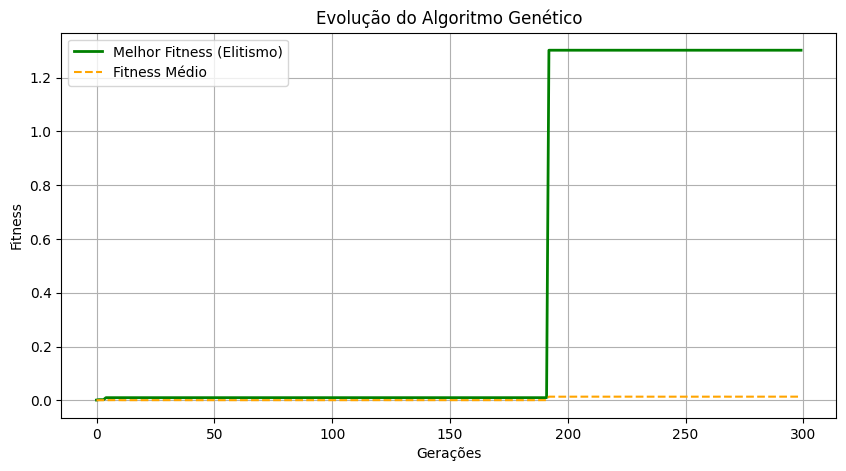

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(melhor_hist, label="Melhor Fitness (Elitismo)", color="green", linewidth=2)
plt.plot(media_hist, label="Fitness Médio", color="orange", linestyle="--")
plt.title("Evolução do Algoritmo Genético")
plt.xlabel("Gerações")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True)
plt.show()

In [170]:
argo_ag.visualizar_resultado_final(melhor_individuo)
argo_ag.passo_a_passo(melhor_individuo)


RESULTADO FINAL DO DESCARREGAMENTO

NÍVEL Z = 1 (Andar 2):
  Col 0  Col 1
L0: [X]  [X] 
L1: [X]  [X] 
L2: [X]  [X] 
L3: [X]  [X] 
L4: [X]  [X] 

NÍVEL Z = 0 (Andar 1):
  Col 0  Col 1
L0: [X]  [X] 
L1: [X]  [X] 
L2: [X]  [X] 
L3: [X]  [X] 
L4: [X]  [X] 

--------------------------------------------------
SUCESSO: Todos os containers foram descarregados!


Descarregamento Passo a Passo
Passo 01:
Garra retira do barco (Y:2, X:1) no andar Z:1
Deixa no pier (Y:5, X:1) no andar Z:1

Passo 02:
Garra retira do barco (Y:2, X:4) no andar Z:1
Deixa no pier (Y:4, X:2) no andar Z:1

Passo 03:
Garra retira do barco (Y:2, X:3) no andar Z:2
Deixa no pier (Y:5, X:2) no andar Z:1

Passo 04:
Garra retira do barco (Y:3, X:2) no andar Z:2
Deixa no pier (Y:4, X:2) no andar Z:2

Passo 05:
Garra retira do barco (Y:4, X:2) no andar Z:1
Deixa no pier (Y:2, X:1) no andar Z:1

Passo 06:
Garra retira do barco (Y:1, X:4) no andar Z:1
Deixa no pier (Y:3, X:1) no andar Z:1

Passo 07:
Garra retira do barco (Y:1, X:3)

## Resultados